# **Project: DNN estimating m_height**

The main task of this project is to create a dataset and using this data set to train a NN model.
For every DNN input, **3 integers** (n=9,m= {2,3,...,n-k},k = {4,5,6}) and **matrix P** (G = (I|P))are given.

To generate the dataset, I use SciPy’s **linprog** to solve linear programs (a linear objective subject to linear equality/inequality constraints). Since linprog minimizes
x by default, we should add minus sign.

Some important data should be generate previously for every sample we want to create using linprog, namely (a, b, X, psi(s_0,s_1...s_m-1)) and G(I|P).

In [2]:
import numpy as np
from itertools import combinations, product
from scipy.optimize import linprog

In [4]:
def Gen_P_matrix(k, n, rng): #k<n

    P = rng.integers(-100, 101, size=(k, n - k), dtype=np.int16)   # sampling uniform in [-100,100]
    return P


There are 5 main constrains to apply, 4 of them are upper bounds.
for example,  for the first s.t. in reading material, we should sum (s_tau-1(j) * g_i,j - s0g_i,a)*ui for every j belongs to set X, which means we have to make a loop
for j in X and add them into the A_ub list, and corresponding 0.0 should also be added j times in b_ub.
And the task for the LP is to find the optimal vector v = [u_0,...u_k-1], v is the x in c = xG in page 2.


original tau function should work as [a][sortedX][b][sortedY],and we should calculate tau-inverse list since it will be used in the LP 

In [8]:
def build_tau_inv(a: int, b: int, X, n: int, m: int) -> np.ndarray:
    X = sorted(set(X))
    tau_inv = np.empty(n, dtype=int)
    tau_inv[a] = 0
    for idx, val in enumerate(X, start=1):
        tau_inv[val] = idx               
    tau_inv[b] = m                       
    Y = sorted(set(range(n)) - {a, b} - set(X))
    for i, j in enumerate(Y, start=m+1):
        tau_inv[j] = i             
    return tau_inv

In [10]:
#test if function tau_inv works
n = 5
a,b = 2,0
m = 3
X = [1,4]
i = build_tau_inv(a,b,X,n,m) # 
print(i)

[3 1 0 4 2]


not all LP has their optimal objective value, according to reading material, if it's unbounded, let z= inf, and if infeasible, z = 0

In [13]:
def solve_z_lp(a,b,m,X,psi,G):

    k, n = G.shape

    #  tau^{-1}
    tau_i = build_tau_inv(a, b, X, n, m)

    #  target：maximize s0 * v_a  => minimize (-s0*g_a)^T u
    s0 = psi[0]
    c  = -s0 * G[:, a]
   
    A_ub, b_ub = [], []

    # j ∈ X： s_{τ^{-1}(j)} v_j <= s0 v_a   和   s_{τ^{-1}(j)} v_j >= 1
    for j in X:
        sj = psi[tau_i[j]]
        A_ub.append(sj * G[:, j] - s0 * G[:, a])
        b_ub.append(0.0)    # <= 0
        A_ub.append(-sj * G[:, j])
        b_ub.append(-1.0)  # <= -1

    # j ∈ Y： |v_j| <= 1
    Y = sorted(set(range(n)) - {a, b} - set(X))
    for j in Y:
        A_ub.append(G[:, j])
        b_ub.append(1.0)     # v_j <= 1
        A_ub.append(-G[:, j])
        b_ub.append(1.0)     # -v_j <= 1

    A_ub = np.vstack(A_ub) if A_ub else np.zeros((0, k))
    b_ub = np.array(b_ub, dtype=float)

    #  v_b = 1  ->  g_b^T u = 1
    A_eq = G[:, b].reshape(1, k)
    b_eq = np.array([1.0])

    bounds = [(None, None)] * k

    z = linprog(c=c, A_ub=A_ub, b_ub=b_ub, A_eq=A_eq, b_eq=b_eq, bounds=bounds, method="highs")
    
    if z.status == 0:    # optimal
        return -z.fun
    if z.status == 2:    # infeasible
        return 0.0
    if z.status == 3:    # unbounded
        return float('inf')
    
    return float('nan')     


In [15]:
#from google.colab import drive
#drive.mount('/content/drive')

For each {a,b,X, psi} and G we can calculate z using LP, and we have to go through every possible value for a,b,X, psi for a given m,n,k and compare z in every case to get the global maximum of z as m-height iteratively.

In [18]:
def m_height_calc(n, k, m, G):
    max_ = -np.inf
    for a in range(n):
        for b in range(n):
            if a == b: 
                continue
            x = [i for i in range(n) if i not in (a, b)]
            for X in combinations(x, m-1):
                for psi in product([-1, 1], repeat=m):
                    z = solve_z_lp(a, b, m, X, psi, G)  #fixed (a,b,X,psi) 
                    if z == float('inf'):
                        return float('inf')
                    if z > max_:
                        max_ = z
    return max_


In [26]:
def Gen_one_sample(n, k, m):
    rng = np.random.default_rng()
    #P = Gen_P_matrix(k, n, rng)
    
    P = [[-8.,  3., -2.,  3., -5.],
       [ 1.,  3., -3., -1.,  7.],
       [ 3., -2.,  1., -1.,  1.],
       [-3.,  3.,  9., -3.,  0.]]
    
    G = np.hstack([np.eye(k), P])
    m_height = m_height_calc(n, k, m, G)
    return m_height, P

In [28]:
m_height,P = Gen_one_sample(9, 4, 3)

In [29]:
print(P)
print(m_height)

[[-8.0, 3.0, -2.0, 3.0, -5.0], [1.0, 3.0, -3.0, -1.0, 7.0], [3.0, -2.0, 1.0, -1.0, 1.0], [-3.0, 3.0, 9.0, -3.0, 0.0]]
33.0


# Create training data using LP

Given n=9, k ={4,5,6}, m ={2,3,...,n-k},save to pickel, and in order to put G into NN, padding is necessary in later steps.

In [27]:
from tqdm import tqdm
import pickle
n = 9
k_space = [4,5,6]

rng = np.random.default_rng(42)

LP_inputs = []
LP_outputs = []
for _ in tqdm(range(500), desc="Generating samples"):
    k = int(rng.choice(k_space))
    m = int(rng.integers(2, n - k + 1))
    m_height, P = Gen_one_sample(n, k, m)
    LP_inputs.append([n, k, m, P])     
    LP_outputs.append(float(m_height))


Generating samples: 100%|█████████████████████| 500/500 [19:19<00:00,  2.32s/it]


In [28]:

with open("LP_inputs.pkl", "wb") as f:
    pickle.dump(LP_inputs, f)

with open("LP_outputs.pkl", "wb") as f:
    pickle.dump(LP_outputs, f)


# Import the given training data, and see if the LP algorithms works well

In [4]:
import pickle, numpy as np, pandas as pd
#import given data
input_2 = 'DS-15-samples_n_k_m_P'
label_2 = 'DS-15-samples_mHeights'
with open(input_2,'rb') as f:
    input_2 = pickle.load(f)
with open(label_2, "rb") as f:
    label_2 = pickle.load(f)
    
#show some rows of data
rows = []
for (n, k, m, P), y in zip(input_2[:10], label_2[:10]):  
    P = np.array(P)
    rows.append({
        "n": n, "k": k, "m": m, 'P': P,
        "P_shape": tuple(P.shape),
        "m_height": y
    })
df = pd.DataFrame(rows)
df.head(3)



FileNotFoundError: [Errno 2] No such file or directory: 'DS-15-samples_n_k_m_P'

# We have to check m-heights are reasonable values, otherwise the DNN will have trouble with training and calculating

In [33]:
import pickle, numpy as np

with open("LP_inputs.pkl", "rb") as f:
    X_list = pickle.load(f)    
with open("LP_outputs.pkl", "rb") as f:
    y_list = pickle.load(f)     

assert len(X_list) == len(y_list), "not the same length"

# create mask: only keep finite results
y = np.asarray(y_list, dtype=float)
mask = mask = np.isfinite(y) & (y >= 1.0)  # filter out inf / nan

print(f"before: {len(y_list)}  after: {mask.sum()}  removed: {(~mask).sum()}")

good_idx = np.where(mask)[0]
X_clean  = [X_list[i] for i in good_idx]
y_clean  = [y_list[i] for i in good_idx]

#save the processed data

with open("LP_inputs.pkl", "wb") as f:
    pickle.dump(X_clean, f)
with open("LP_outputs.pkl", "wb") as f:
    pickle.dump(y_clean, f)


before: 500  after: 481  removed: 19


# Combine the training data with LP and the given training data

In [35]:

#import self-created data
input_1 = 'LP_inputs.pkl'
label_1 = 'LP_outputs.pkl'
with open(input_1,'rb') as f:
     input_1 = pickle.load(f)
with open(label_1, "rb") as f:
    label_1 = pickle.load(f)
inputs  = [[n, k, m, np.asarray(P, float)] for (n, k, m, P) in input_1]
targets = [float(y) for y in label_1]

In [36]:
#merge
all_inputs = list(input_2) + list(input_1)
all_targets = list(label_2) + list(label_1) 

assert len(all_inputs) == len(all_targets), "inputs and targets not same length!"
print(f'We have {len(all_targets)} samples')

We have 32568 samples


In [24]:
#padding to 6*5
def padding_one_P(P,k,n = 9):
    P = np.asarray(P, np.float32)  # shape: k × (n-k)
    P_ = np.zeros((6, 5), dtype=np.float32)
    P_[:k, :n-k] = P
    return P_

In [2]:
#data processing, since the cost func is (logy - logy')^2, so we can calculate the label into log(y) previously
from tqdm import tqdm

P_pads, ks, ms,ns, y_log2 = [], [], [], [],[]
N = len(all_inputs)
for (n, k, m, P), y in tqdm(zip(all_inputs, all_targets)):
    P_pad = padding_one_P(P, k, n=9)
    P_pads.append(P_pad)
    ks.append(k)
    ms.append(m)
    ns.append(n)
    y_log2.append(np.log2(max(float(y), 1.0))) 
    
P_pads = np.stack(P_pads)   # (N-samples, 6, 5)
P_flat = P_pads.reshape(N, -1)  #(N,30)
ks = np.array(ks, np.float32)[:, None]          # (N, 1)
ns = np.array(ns, np.float32)[:, None]          # (N, 1)
ms = np.array(ms, np.float32)[:, None]          # (N, 1)
y_log2 = np.array(y_log2, np.float32)           # (N,)

X = np.concatenate([ns,ks, ms, P_flat], axis=1)  # shape = (N, 1+1+1+6*5 = 33)


NameError: name 'all_inputs' is not defined

In [28]:
# check if inf exists
import numpy as np

def check_targets(y):
    y = np.asarray(y)
    print("dtype:", y.dtype, "shape:", y.shape)

    n_nan    = np.isnan(y).sum()
    n_pinf   = np.isposinf(y).sum()
    n_ninf   = np.isneginf(y).sum()
    n_finite = np.isfinite(y).sum()

    print(f"NaN: {n_nan}, +Inf: {n_pinf}, -Inf: {n_ninf}, finite: {n_finite}")

    if n_nan or n_pinf or n_ninf:
    
        bad_idx = np.where(~np.isfinite(y))[0]
        print("Bad indices (first 10):", bad_idx[:10])
        print("Bad values (first 10):", y[bad_idx[:10]])
    return n_nan, n_pinf, n_ninf

check_targets(y_log2)


dtype: float64 shape: (0,)
NaN: 0, +Inf: 0, -Inf: 0, finite: 0


(0, 0, 0)

In [41]:
#data split: randomly permutation the data, set 80% previous part as training set
rng = np.random.default_rng(2025)
perm = rng.permutation(len(X))

s = int(0.8 * len(X))
idx_tr, idx_va = perm[:s], perm[s:]

X_train, y_train = X[idx_tr], y_log2[idx_tr]
X_valid, y_valid = X[idx_va], y_log2[idx_va]

# Create Neuron Network Model

In [43]:
import tensorflow as tf
from tensorflow import keras
from keras.layers import Dense, Input, Dropout
from tensorflow.keras import layers ,regularizers

norm = layers.Normalization()  
norm.adapt(X_train) 
# inputdata being normalized
#the inpus has been flattened, so the shape is 33 (1+1+1+6*5)
model = keras.Sequential([
    layers.Input(shape=(33,)),  
    norm, 
    layers.Dense(256, activation='relu',kernel_regularizer=regularizers.l2(1e-4)),
    layers.Dropout(0.3),
    layers.Dense(128, activation='relu',kernel_regularizer=regularizers.l2(1e-4)),
    layers.Dropout(0.3),
    layers.Dense(1, activation='linear')  
])
model.compile(optimizer='adam', loss='mse', metrics=['mae','mse'])

history = model.fit(X_train, y_train, validation_data=(X_valid, y_valid),
          epochs=100, batch_size=64,
          callbacks=[keras.callbacks.EarlyStopping(
              monitor='val_loss', patience=10, restore_best_weights=True)])


Epoch 1/100
408/408 ━━━━━━━━━━━━━━━━━━━━ 1s 743us/step - loss: 8.0365 - mae: 2.0842 - mse: 8.0133 - val_loss: 2.4337 - val_mae: 1.1866 - val_mse: 2.4109
Epoch 2/100
408/408 ━━━━━━━━━━━━━━━━━━━━ 0s 610us/step - loss: 3.2078 - mae: 1.3539 - mse: 3.1853 - val_loss: 2.2238 - val_mae: 1.1183 - val_mse: 2.2015
Epoch 3/100
408/408 ━━━━━━━━━━━━━━━━━━━━ 0s 609us/step - loss: 2.9435 - mae: 1.2893 - mse: 2.9214 - val_loss: 2.0051 - val_mae: 1.0500 - val_mse: 1.9831
Epoch 4/100
408/408 ━━━━━━━━━━━━━━━━━━━━ 0s 597us/step - loss: 2.8563 - mae: 1.2655 - mse: 2.8344 - val_loss: 1.9104 - val_mae: 1.0250 - val_mse: 1.8887
Epoch 5/100
408/408 ━━━━━━━━━━━━━━━━━━━━ 0s 622us/step - loss: 2.6784 - mae: 1.2217 - mse: 2.6567 - val_loss: 1.9384 - val_mae: 1.0237 - val_mse: 1.9167
Epoch 6/100
408/408 ━━━━━━━━━━━━━━━━━━━━ 0s 597us/step - loss: 2.5580 - mae: 1.1927 - mse: 2.5362 - val_loss: 1.7525 - val_mae: 0.9488 - val_mse: 1.7306
Epoch 7/100
408/408 ━━━━━━━━━━━━━━━━━━━━ 0s 611us/step - loss: 2.4199 - mae: 1.147

dict_keys(['loss', 'mae', 'mse', 'val_loss', 'val_mae', 'val_mse'])


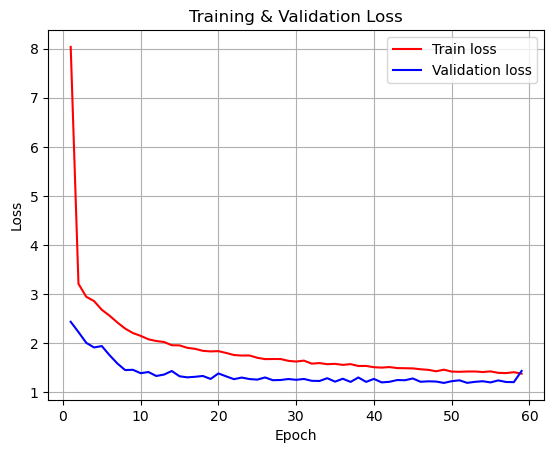

In [44]:
print(history.history.keys()) 

train_loss = history.history["loss"]
val_loss   = history.history["val_loss"]  

epochs = range(1, len(train_loss) + 1)

import matplotlib.pyplot as plt
plt.plot(epochs, train_loss, "r-", label="Train loss")
plt.plot(epochs, val_loss,   "b-", label="Validation loss")
plt.xlabel("Epoch"); plt.ylabel("Loss"); plt.title("Training & Validation Loss")
plt.legend(); plt.grid(True); plt.show()


In [45]:
model.save("mheight_log2_model.keras") 

# Predict the test data

In [18]:
import pickle
import numpy as np
import tensorflow as tf
from tensorflow import keras
import os
print(os.getcwd())
print("当前目录文件列表：", os.listdir())

/Users/xiaoyunchu/Documents/636 DL/Project1
当前目录文件列表： ['.DS_Store', 'DS-15-samples_mHeights', 'Project.ipynb', 'LP_outputs.pkl', 'DS-1-Test-n_k_m_P', 'LP_inputs.pkl', '.ipynb_checkpoints', 'mheight_log2_model.keras', '2025-9-18-636-Project-DNN-for-mHeight.pdf', 'DS-15-samples_n_k_m_P']


In [20]:
#load data
sample_file = "DS-1-Test-n_k_m_P" 
with open(sample_file, "rb") as f:
    sample_inputs = pickle.load(f) 

In [30]:
P_pads, ks, ms, ns = [], [], [], []
for (n, k, m, P) in sample_inputs:
    P_pad = padding_one_P(P, k, n=9)
    P_pads.append(P_pad)
    ks.append(k)
    ms.append(m)
    ns.append(n)

P_pads = np.stack(P_pads)
P_flat = P_pads.reshape(len(sample_inputs), -1)
ks = np.array(ks, np.float32)[:, None]
ms = np.array(ms, np.float32)[:, None]
ns = np.array(ns, np.float32)[:, None]
X_test = np.concatenate([ns, ks, ms, P_flat], axis=1).astype(np.float32)
print("Shape of test data:", X_test.shape)



Shape of test data: (7281, 33)


In [34]:
# load trained model
model = keras.models.load_model("mheight_log2_model.keras")  
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ normalization (Normalization)   │ (None, 33)             │            67 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │         8,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 125,256 (489.29 KB)

 Trainable params: 41,729 (163.00 KB)

 Non-trainable params: 67 (272.00 B)

 Optimizer params: 83,460 (326.02 KB)

In [36]:
y_pred_log2 = model.predict(X_test).squeeze()
y_pred = np.power(2, y_pred_log2)

228/228 ━━━━━━━━━━━━━━━━━━━━ 0s 213us/step


In [38]:
output_filename = "CSCE 636-600 Fall 2025 Project 1 Test Results Xiaoyun Chu UIN231002795.pkl"
with open(output_filename, "wb") as f:
    pickle.dump(list(y_pred), f)

print("✅ Saved predictions to:", output_filename)

✅ Saved predictions to: CSCE 636-600 Fall 2025 Project 1 Test Results Xiaoyun Chu UIN231002795.pkl


In [ ]:
first_input = sample_inputs[1]
print("input first sample：")
print("n, k, m =", first_input[0], first_input[1], first_input[2])
print("P shape of samples：", np.array(first_input[3]).shape)
print("P =\n", np.array(first_input[3]))


第一个输入样本：
n, k, m = 9 5 3
P 矩阵形状： (5, 4)
P =
 [[  0. -30.  82. -17.]
 [ 47.  17. -13.   1.]
 [ 42. -14.  92.  81.]
 [ 39. -41. -80.  11.]
 [ 47.  27.  28. -66.]]


In [78]:
with open("CSCE 636-600 Fall 2025 Project 1 Test Results Xiaoyun Chu UIN231002795.pkl", "rb") as f:
    output_data = pickle.load(f)


In [ ]:
print("first sample（real m-height）:", output_data[1])


第一个输出样本（真实 m-height）: 784.0684


In [ ]:
import pickle
import numpy as np

filename = 'CSCE 636-600 Fall 2025 Project 1 Test Results Xiaoyun Chu UIN231002795.pkl'
with open(filename, "rb") as f:
    mheights = pickle.load(f)

mheights = np.array(mheights, dtype=float)

# === Step 2: check if neg values exist ===
neg_mask = mheights < 0
num_neg = np.sum(neg_mask)

if num_neg > 0:
    print(f"⚠️ 发现 {num_neg} 个 m-height < 0")
    print("其中一些示例值：", mheights[neg_mask][:10])
else:
    print("✅ all m-height  ≥ 0")

print(f"num of samples: {len(mheights)}")
print(f"min value: {mheights.min():.6f}, max: {mheights.max():.6f}, avg: {mheights.mean():.6f}")


✅ 所有 m-height 都 ≥ 0
样本总数: 7281
最小值: 4.357402, 最大值: 58154.003906, 平均值: 3601.538386
